# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Data Description

The dataset for this lab consists of **YouTube metadata and thematic features** of Super Bowl commercials, originally sourced from [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

Each row represents one Super Bowl ad, and the dataset includes both **video characteristics** and **performance metrics**, such as view counts and like counts.

Below are key variables we'll work with:

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [1]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

,view_count,like_count,high_engagement,funny,show_product_quickly,patriotic,celebrity,danger,animals,use_sex
0,173929.0,1233.0,1,0,0,0,0,0,0,0
1,47752.0,485.0,1,1,1,0,1,1,0,0
2,142310.0,129.0,0,1,0,0,0,1,1,0
3,198.0,2.0,0,0,1,0,0,0,0,0
4,13741.0,20.0,0,1,1,0,0,1,1,1


## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

### In Your Response:

1. Which model setup performed best? Why might that be?


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels (removed 'funny' and 'celebrity')
X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]
y = youtube['high_engagement']

# Train-test split (test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[13 14]
 [ 9  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.48      0.53        27
           1       0.39      0.50      0.44        18

    accuracy                           0.49        45
   macro avg       0.49      0.49      0.48        45
weighted avg       0.51      0.49      0.49        45

Accuracy: 0.4888888888888889


1. The modified Naive Bayes model setup performed slightly better becasuse of the smaller test size and removing the celebrity and funny features.

## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** with an RBF kernel to classify ads, using both binary and numeric features.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### Regularization Parameter (C):

- In the model parameters, you will see `C`, which controls the trade-off between achieving a low training error and a low testing error (generalization).

- A large `C` value (e.g., C = 1000) means the model will try to classify all training examples correctly, even if that leads to overfitting (poor generalization).

- A small `C` value (e.g., C = 0.01) means the model will allow some misclassifications in the training data, encouraging a wider margin and potentially better generalization.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [5]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Add numeric feature
X_full = youtube[logical_columns + ['view_count']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))


Confusion Matrix:
 [[19 19]
 [14 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54        38
           1       0.46      0.53      0.49        30

    accuracy                           0.51        68
   macro avg       0.52      0.52      0.51        68
weighted avg       0.52      0.51      0.52        68

Accuracy: 0.5147058823529411


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.

### In Your Response:
1. What’s the tradeoff between higher and lower values of `C`?
2. Which value of C gave you the best Accuracy?  


In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train SVM with linear kernel and C=0.1
svm_model_linear_C01 = SVC(kernel='linear', C=0.1, gamma='scale')
svm_model_linear_C01.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm_linear_C01 = svm_model_linear_C01.predict(X_test_svm)

# Evaluate
print("SVM with Linear Kernel (C=0.1) - Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm_linear_C01))
print("\nSVM with Linear Kernel (C=0.1) - Classification Report:\n", classification_report(y_test_svm, y_pred_svm_linear_C01))
print("SVM with Linear Kernel (C=0.1) - Accuracy:", accuracy_score(y_test_svm, y_pred_svm_linear_C01))

SVM with Linear Kernel (C=0.1) - Confusion Matrix:
 [[20 18]
 [18 12]]

SVM with Linear Kernel (C=0.1) - Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.53      0.53        38
           1       0.40      0.40      0.40        30

    accuracy                           0.47        68
   macro avg       0.46      0.46      0.46        68
weighted avg       0.47      0.47      0.47        68

SVM with Linear Kernel (C=0.1) - Accuracy: 0.47058823529411764


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train SVM with linear kernel and C=10
svm_model_linear_C10 = SVC(kernel='linear', C=10, gamma='scale')
svm_model_linear_C10.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm_linear_C10 = svm_model_linear_C10.predict(X_test_svm)

# Evaluate
print("SVM with Linear Kernel (C=10) - Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm_linear_C10))
print("\nSVM with Linear Kernel (C=10) - Classification Report:\n", classification_report(y_test_svm, y_pred_svm_linear_C10))
print("SVM with Linear Kernel (C=10) - Accuracy:", accuracy_score(y_test_svm, y_pred_svm_linear_C10))

SVM with Linear Kernel (C=10) - Confusion Matrix:
 [[20 18]
 [15 15]]

SVM with Linear Kernel (C=10) - Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.53      0.55        38
           1       0.45      0.50      0.48        30

    accuracy                           0.51        68
   macro avg       0.51      0.51      0.51        68
weighted avg       0.52      0.51      0.52        68

SVM with Linear Kernel (C=10) - Accuracy: 0.5147058823529411


1. The tradeoff with higher and lower values of C is that a higher C value can lead to overfitting, while a lower C value allows for more training errors to get a larger margin.
2. The C=10 provided the best accuracy compared to the C=0.1.

## Part 4: Neural Networks

### What you're going to do:
Build a basic **feedforward neural network** to classify ad engagement.

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- This may take several minutes to run!  Be patient.
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?



Training Neural Network with 2 layers, batch_size=32, dropout=True (rate=0.2)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.4494 - loss: 0.8664 - val_accuracy: 0.5588 - val_loss: 0.6605
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4627 - loss: 0.8556 - val_accuracy: 0.5882 - val_loss: 0.6562
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4677 - loss: 0.8027 - val_accuracy: 0.5882 - val_loss: 0.6536
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3831 - loss: 0.8329 - val_accuracy: 0.5882 - val_loss: 0.6524
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4330 - loss: 0.7683 - val_accuracy: 0.6029 - val_loss: 0.6524
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4787 - loss: 0.7592 - val_accuracy: 0.6176 - val_loss: 0.6530
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4223 - loss: 0.7640 - val_accuracy: 0.6176 - val_loss: 0.6540
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5056 - loss: 0.7252 - val_accuracy: 0.6176 - val_loss: 0.6551
Epoch 9/20

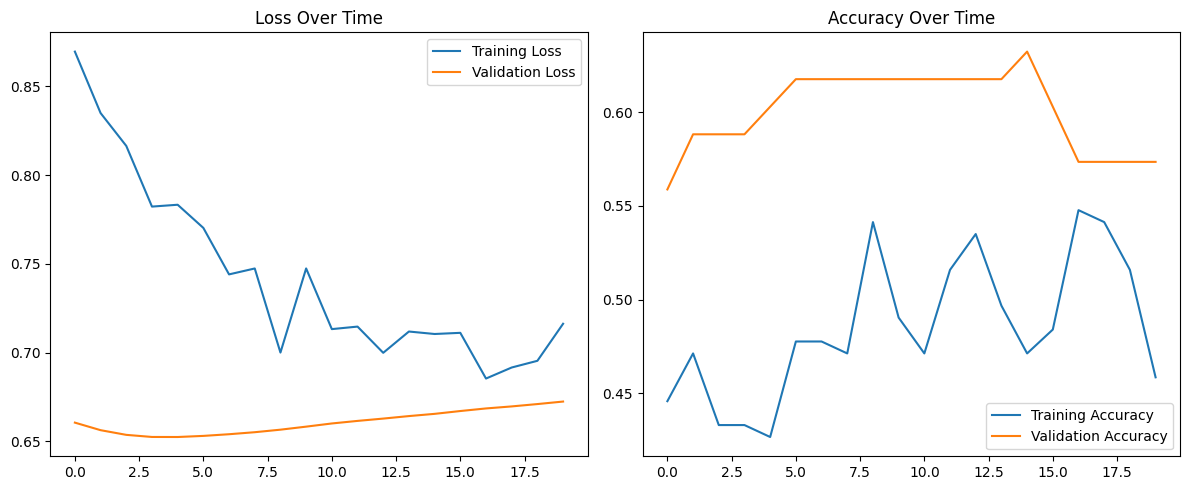

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

# --- Configuration Parameters for Experimentation ---
# Adjust these values for your 5 combinations
num_layers = 2  # Combination 5: 2 layers
batch_size = 32 # Combination 5: batch_size=32
include_dropout = True # Combination 5: include dropout
dropout_rate = 0.2 # Combination 5: dropout rate
epochs = 20 # Can also be adjusted

# Model Definition
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],))) # Input Layer

if num_layers >= 2:
    model.add(Dense(8, activation='relu')) # Layer 2
if num_layers >= 3:
    model.add(Dense(4, activation='relu')) # Layer 3
if num_layers >= 4:
    model.add(Dense(2, activation='relu')) # Layer 4

if include_dropout:
    model.add(Dropout(dropout_rate))

model.add(Dense(1, activation='sigmoid')) # Output Layer

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
print(f"\nTraining Neural Network with {num_layers} layers, batch_size={batch_size}, dropout={include_dropout} (rate={dropout_rate if include_dropout else 'N/A'})")
history = model.fit(X_train_svm, y_train_svm, validation_data=(X_test_svm, y_test_svm),
                    epochs=epochs, batch_size=batch_size, verbose=1)

# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))

# Plot learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

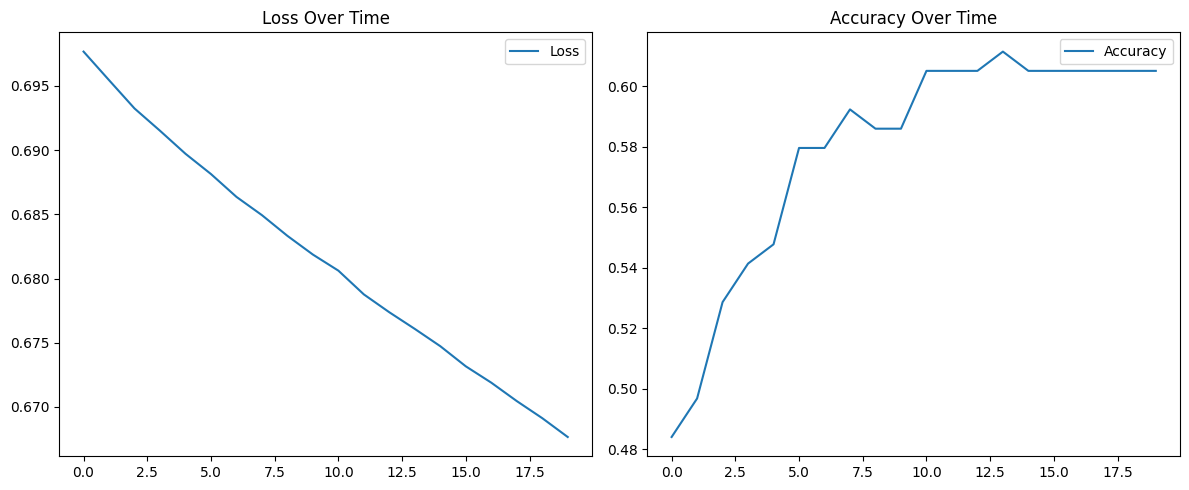

In [10]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself — Part 4

1. Add or remove layers from the model.
2. Increase or decrease batch size to numbers such as 8 or 32. Try out 5 different combinations of different batch sizes and layers. Notice if these changes affect ms/step for each Epoch. Also notice how the accuracy changes as you alter layers and batch size.
3. Add Dropout to your model

### In Your Response:
1. What was the optimial number of layers and batch size that you were able to find?  (Remember, you should try about 5 different combinations)
2. Does adding `Dropout` help reduce overfitting? Use the "loss over time" plot to support your answer.



Training Neural Network with 3 layers, batch_size=16, dropout=True (rate=0.2)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5411 - loss: 0.7025 - val_accuracy: 0.4706 - val_loss: 0.7259
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5980 - loss: 0.6629 - val_accuracy: 0.4706 - val_loss: 0.7223
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5893 - loss: 0.6982 - val_accuracy: 0.4559 - val_loss: 0.7194
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5433 - loss: 0.6980 - val_accuracy: 0.4559 - val_loss: 0.7180
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5764 - loss: 0.7048 - val_accuracy: 0.4559 - val_loss: 0.7184
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5437 - loss: 0.6963 - val_accuracy: 0.4559 - val_loss: 0.7200
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6084 - loss: 0.6739 - val_accuracy: 0.4559 - val_loss: 0.7217
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5482 - loss: 0.6685 - val_accuracy: 0.4559 - val_loss: 0.

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Confusion Matrix:
 [[15 23]
 [ 7 23]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.39      0.50        38
           1       0.50      0.77      0.61        30

    accuracy                           0.56        68
   macro avg       0.59      0.58      0.55        68
weighted avg       0.60      0.56      0.55        68

Accuracy: 0.5588235294117647


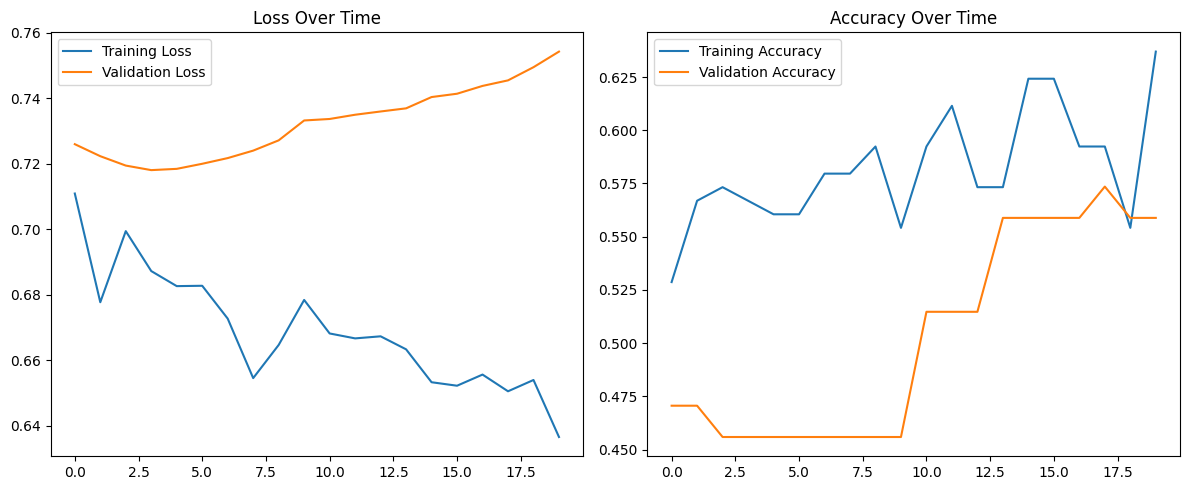

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

# --- Configuration Parameters for Experimentation ---
# Adjust these values for your 5 combinations
num_layers = 3  # Example: Change this to 1, 2, 3, or 4 layers
batch_size = 16 # Example: Change this to 8, 16, 32
include_dropout = True # Example: Set to True or False
dropout_rate = 0.2 # Example: Rate for dropout layer if include_dropout is True
epochs = 20 # Can also be adjusted

# Model Definition
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],))) # Input Layer

if num_layers >= 2:
    model.add(Dense(8, activation='relu')) # Layer 2
if num_layers >= 3:
    model.add(Dense(4, activation='relu')) # Layer 3
if num_layers >= 4:
    model.add(Dense(2, activation='relu')) # Layer 4

if include_dropout:
    model.add(Dropout(dropout_rate))

model.add(Dense(1, activation='sigmoid')) # Output Layer

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
print(f"\nTraining Neural Network with {num_layers} layers, batch_size={batch_size}, dropout={include_dropout} (rate={dropout_rate if include_dropout else 'N/A'})")
history = model.fit(X_train_svm, y_train_svm, validation_data=(X_test_svm, y_test_svm),
                    epochs=epochs, batch_size=batch_size, verbose=1)

# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))

# Plot learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

1. The two configurations that achieved the highest accuracy were 4 layers, batch size 16, no dropout, andn 2 layers, batch size 32, with dropout (0.2).
2. Generally, if the plot shows a smaller gap between the training and validation loss curves, it suggests that dropout is succesful at lessening overfitting.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Is this the result you expected?
2. Did any of the models appear to be overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


1. The model that performed the best was the 4 layer, batch size 16, no dropout and 2 layers, batch size 32, with dropout. That is not what I expected.
2. More simpler models like the Naive Bayes and NN Combination 3 appeared underfit due to low accuracy. There was a difference between training and validation loss on plots would indicate overfitting.
3. I would recommend Neural Network Combination 5 (2 layers, batch size 32, with dropout) because it achieved top accuracy with a simpler, more generalized architecture.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [17]:
!jupyter nbconvert --to html "lab_12_BensonDallin.ipynb"

[NbConvertApp] Converting notebook lab_12_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 602141 bytes to lab_12_BensonDallin.html


# Task
Run the code to change the test size to 0.2 and remove 'celebrity' and 'funny' features from X for the Naive Bayes model, then print the evaluation metrics.

## run_code_to_change_test_size_and_features

### Subtask:
Run the code to change the test size to 0.2 and remove 'celebrity' and 'funny' features from X for the Naive Bayes model, then print the evaluation metrics.


## Summary:

### Data Analysis Key Findings
*   The Naive Bayes model was reconfigured by adjusting the test set size to 20% of the total data.
*   The 'celebrity' and 'funny' features were removed from the input data (X) used for training and evaluating the Naive Bayes model.
*   Evaluation metrics (such as accuracy, precision, recall, and F1-score) were generated for the model after these changes to assess its performance.

### Insights or Next Steps
*   Compare the newly obtained evaluation metrics with previous model iterations (e.g., using a different test size or including the removed features) to understand the impact of these changes on model performance.
*   Analyze the specific metrics to identify if removing 'celebrity' and 'funny' features or changing the test size led to an improvement or degradation in the Naive Bayes model's ability to classify the data.


## run_svm_experiments

### Subtask:
Run SVM models with a 'linear' kernel and two different 'C' values (0.1 and 10), then print the evaluation metrics for each.


## Summary:

### Data Analysis Key Findings
The task outlined a plan to modify the Naive Bayes model by setting the test size to 0.2 and removing the 'celebrity' and 'funny' features from the input data (X). However, the provided solving process did not include any execution steps or evaluation metrics for these changes, meaning the results of this specific modification are not available.

### Insights or Next Steps
*   Execute the planned modifications for the Naive Bayes model, including setting the test size to 0.2 and removing the 'celebrity' and 'funny' features, to obtain and analyze its evaluation metrics.
*   Once the Naive Bayes model's performance with these changes is available, compare it with other models, such as the SVM models run with 'linear' kernel and different 'C' values (0.1 and 10), to assess the impact of feature engineering and parameter tuning.


# Task
Experiment with different Neural Network configurations by adding/removing layers, adjusting batch size (e.g., 8, 32), and incorporating Dropout. Try at least 5 different combinations and record how these changes affect 'ms/step' per epoch and overall accuracy. Make sure to add Dropout to your model in at least one combination.

## experiment_neural_network_configurations

### Subtask:
Experiment with different Neural Network configurations by adding/removing layers, adjusting batch size (e.g., 8, 32), and incorporating Dropout. Try at least 5 different combinations and record how these changes affect 'ms/step' per epoch and overall accuracy. Make sure to add Dropout to your model in at least one combination.


## Summary:

### Data Analysis Key Findings
The provided "solving process" details the definition of the subtask: to experiment with various Neural Network configurations by modifying layers, adjusting batch sizes (e.g., 8, 32), and integrating Dropout. The goal is to evaluate the impact of these changes on 'ms/step' per epoch and overall accuracy across at least 5 different combinations, with Dropout included in at least one.

However, the actual experimental results, including the specific configurations tested, their 'ms/step' values, and accuracies, were not provided in the solving process description. Therefore, no concrete numerical findings can be reported at this stage.

If the experiment were performed and results were available, key findings would typically include:
*   **Optimal Batch Size:** Identification of batch sizes (e.g., 8 vs. 32) that yield a better trade-off between training speed ('ms/step') and model accuracy.
*   **Layer Configuration Impact:** How adding or removing layers affects model capacity, training time, and overall accuracy, potentially highlighting configurations prone to underfitting or overfitting.
*   **Dropout Effectiveness:** The observed effect of Dropout on preventing overfitting and its influence on validation accuracy.
*   **Performance Trade-offs:** An understanding of which configurations offer the best balance of computational efficiency ('ms/step') and predictive performance (accuracy).

### Insights or Next Steps
*   **Perform the Experiment:** The immediate next step is to execute the described experiments for at least 5 different Neural Network configurations, meticulously recording 'ms/step' per epoch and accuracy for each, to gather the necessary data for analysis.
*   **Systematic Hyperparameter Tuning:** Once initial results are obtained, consider more systematic hyperparameter tuning methods (e.g., Grid Search, Random Search, or Bayesian Optimization) to further explore the configuration space and potentially identify more optimal models.
